# XGBoost Classification Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/UCI_Credit_Card.csv')
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [2]:
target_col = 'default.payment.next.month'

X = df.drop(columns=['ID', target_col])
y = df[target_col]
X = pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}")

Train size: (37382, 30), Test size: (6000, 30)


In [3]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

base_xgb = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')

xgb_random = RandomizedSearchCV(estimator=base_xgb, param_distributions=param_dist,
                                n_iter=10, cv=3, scoring='f1', n_jobs=-1,
                                verbose=2, random_state=42)

print("Starting Randomized Search...")
xgb_random.fit(X_train_scaled, y_train_resampled)

print(f"Best Parameters Found: {xgb_random.best_params_}")
print(f"Best F1 Score from CV: {xgb_random.best_score_:.4f}")

xgb_classifier = xgb_random.best_estimator_

Starting Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best F1 Score from CV: 0.7613


Accuracy: 0.8002

-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      4673
           1       0.56      0.44      0.50      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.67      0.69      6000
weighted avg       0.79      0.80      0.79      6000

-------------------------------------------------------


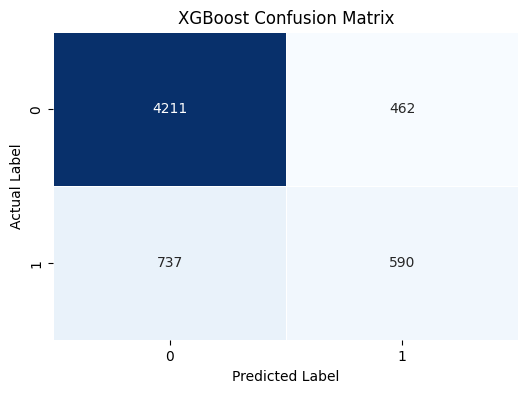

In [4]:
y_pred = xgb_classifier.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}\n")
print("-" * 55)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("-" * 55)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Top 10 Feature Ranking:
1. MARRIAGE_2 (0.2767)
2. PAY_0 (0.1097)
3. EDUCATION_1 (0.1027)
4. PAY_2 (0.0826)
5. EDUCATION_3 (0.0670)
6. MARRIAGE_1 (0.0591)
7. PAY_3 (0.0442)
8. EDUCATION_2 (0.0384)
9. PAY_AMT1 (0.0232)
10. LIMIT_BAL (0.0183)


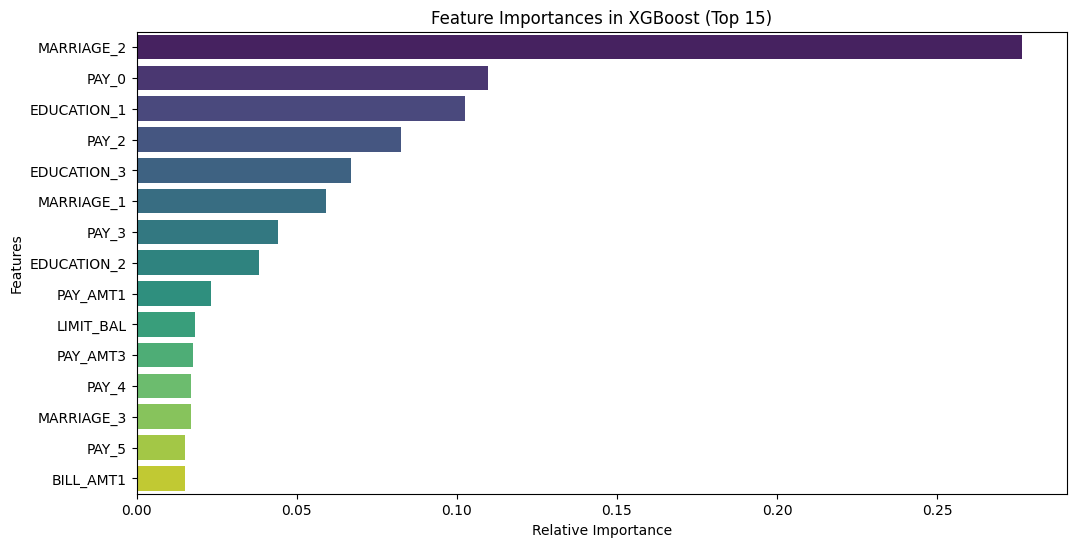

In [5]:
importances = xgb_classifier.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

print("Top 10 Feature Ranking:")
for f in range(10):
    print(f"{f + 1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

plt.figure(figsize=(12, 6))
plt.title("Feature Importances in XGBoost (Top 15)")
sns.barplot(x=importances[indices][:15], y=feature_names[indices][:15], palette='viridis')
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()